# Ensemble Methods — Beginner-Friendly Guide
*Covers Lectures 9.1 & 9.2*

---

## What are ensemble methods?

An **ensemble method** is a machine-learning technique that combines the predictions of **multiple models** into a single, more accurate prediction.

The core idea is beautifully simple:

> **No single model is perfect, but different models make different mistakes. When we combine them, the mistakes cancel out.**

Think of it like asking a group of people to guess how many jellybeans are in a jar. Each person's guess has some error, but the **average** of all their guesses is usually far more accurate than any individual guess. This is called the [wisdom of crowds](https://www.youtube.com/watch?v=iOucwX7Z1HU&t=203s) — and it's exactly the intuition behind ensemble learning.

In these notes we cover **four** ensemble concepts from Lectures 9.1 and 9.2:

| # | Method | Key idea |
|---|--------|----------|
| 1 | **Hard Voting** | Combine *different* model types by majority vote |
| 2 | **Bagging** | Train many copies of the *same* model on random bootstrap samples |
| 3 | **AdaBoost** | Train models sequentially; each focuses on the mistakes of the last |
| 4 | **Gradient Boosting** | Train models sequentially; each corrects the *residual errors* of the last |

---

## Setup — imports and data

We use the **Iris dataset** (same as the lecture).  The task: distinguish
*versicolor* (class 0) from *virginica* (class 1) using sepal length and
sepal width — a deliberately tricky 2-feature problem so we can visualise
the decision boundaries.


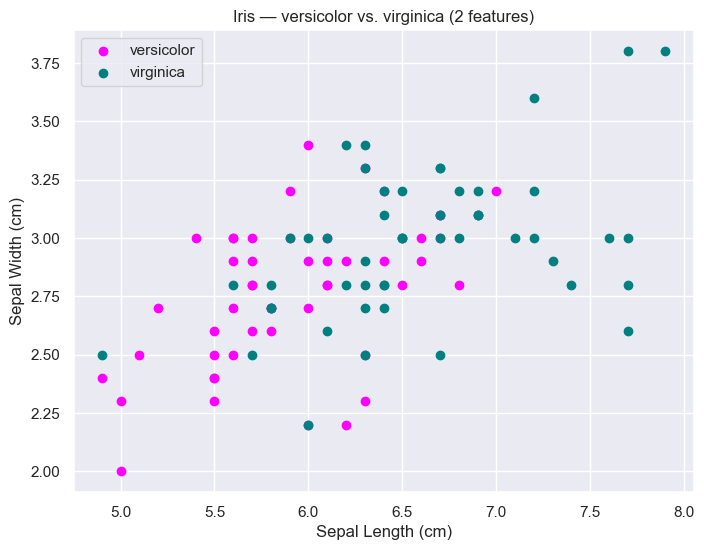

Shape of X: (100, 2)
Class distribution: {np.int64(0): np.int64(50), np.int64(1): np.int64(50)}


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

sns.set_theme()

# ── Load the Iris data and keep only versicolor vs. virginica ──────────────
iris = sns.load_dataset("iris")
iris = iris.iloc[50:]          # rows 50-149 = versicolor + virginica

# Two features only so we can plot decision regions later
X_2d = iris[["sepal_length", "sepal_width"]].to_numpy()

# Labels: 0 = versicolor, 1 = virginica
def make_labels(y):
    return 0 if y == "versicolor" else 1

y = iris["species"].map(make_labels).to_numpy()

# ── Quick scatter plot ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
for species, color in [("versicolor", "magenta"), ("virginica", "teal")]:
    mask = iris["species"] == species
    ax.scatter(iris.loc[mask, "sepal_length"],
               iris.loc[mask, "sepal_width"],
               c=color, label=species)
ax.set_xlabel("Sepal Length (cm)", fontsize=12)
ax.set_ylabel("Sepal Width (cm)",  fontsize=12)
ax.legend()
ax.set_title("Iris — versicolor vs. virginica (2 features)")
plt.show()

print("Shape of X:", X_2d.shape)
print("Class distribution:", dict(zip(*np.unique(y, return_counts=True))))


---

## 1. Hard Voting

### The concept

A **Hard Voting Classifier** combines several *different* model types.
Each model gets one vote, and whichever class gets the most votes wins.

```
       SVM     →  class 1 ─┐
  Logistic Reg →  class 0 ─┼─▶  majority vote  ─▶  class 1
  Random Forest →  class 1 ─┘
```

Why does this work?  Because different model families have different
strengths and weaknesses:
- **SVM** is great at high-dimensional data but can struggle with noisy features.
- **Logistic Regression** is fast and interpretable but assumes linearity.
- **Random Forest** handles non-linearity but can overfit on small data.

When we take the majority vote, each model's weakness is *covered* by the others.

### Code


In [2]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# ── Split data ────────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_2d, y, test_size=0.4, random_state=9
)

# ── Three individual models ────────────────────────────────────────────────
log_clf = LogisticRegression(max_iter=1000)
rnd_clf = RandomForestClassifier(random_state=42)
svm_clf = SVC()

# ── Hard Voting ensemble ───────────────────────────────────────────────────
# VotingClassifier takes a list of (name, model) tuples
voting_clf = VotingClassifier(
    estimators=[("lr", log_clf), ("rf", rnd_clf), ("svm", svm_clf)],
    voting="hard"
)

# ── Train & evaluate each model individually, then the ensemble ────────────
results = {}
for name, clf in [("SVM", svm_clf),
                  ("Logistic Regression", log_clf),
                  ("Random Forest", rnd_clf),
                  ("Hard Voting", voting_clf)]:
    clf.fit(X_train, y_train)
    acc = accuracy_score(y_test, clf.predict(X_test))
    results[name] = round(acc, 3)
    print(f"{name:20s}  accuracy = {acc:.3f}")

print()
print("Notice: the voting classifier often beats (or ties) each individual model!")


SVM                   accuracy = 0.750
Logistic Regression   accuracy = 0.700
Random Forest         accuracy = 0.500
Hard Voting           accuracy = 0.700

Notice: the voting classifier often beats (or ties) each individual model!


### What to look for

- The ensemble accuracy should be **≥ the best individual model**, often higher.
- The more *diverse* the models, the bigger the gain.  Combining three identical
  models gives you nothing — they all make the same mistakes!


---

## 2. Bagging  (Bootstrap AGGregating)

### The concept

**Bagging** uses the same base model type, but trains each copy on a
different **bootstrap sample** of the training data.

#### What is a bootstrap sample?
A bootstrap sample is created by randomly picking N samples **with replacement**
from the original N training points.  This means:
- Some samples appear **2 or 3 times** in a bootstrap sample.
- About **37 %** of samples are never picked at all (called "out-of-bag").

Each copy sees slightly different data → makes slightly different errors →
combining them reduces overall error.

```
Training data  ─────────────────────────────
                │                           │
         Bootstrap 1  Bootstrap 2  Bootstrap 3  …
                │                           │
            Tree 1     Tree 2      Tree 3   …
                └───────────┬───────────────┘
                        Majority vote
                            │
                      Final prediction
```

### A "decision stump" — the weakest possible learner

Bagging works best with **weak learners** — models that are only slightly
better than random guessing.  The most common choice is a
**decision stump**: a decision tree with `max_depth=1` (a single split).

Individually, stumps are terrible.  Together, hundreds of them become powerful.


In [3]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier

# ── Baseline: a single stump vs. a single deeper tree ─────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_2d, y, test_size=0.4, random_state=6
)

stump = DecisionTreeClassifier(max_depth=1, random_state=42)
stump.fit(X_train, y_train)
print("Single stump accuracy:", accuracy_score(y_test, stump.predict(X_test)))
print(classification_report(y_test, stump.predict(X_test)))

tree = DecisionTreeClassifier(max_depth=6, random_state=42)
tree.fit(X_train, y_train)
print("Deeper tree accuracy:", accuracy_score(y_test, tree.predict(X_test)))
print(classification_report(y_test, tree.predict(X_test)))


Single stump accuracy: 0.625
              precision    recall  f1-score   support

           0       0.57      1.00      0.73        20
           1       1.00      0.25      0.40        20

    accuracy                           0.62        40
   macro avg       0.79      0.62      0.56        40
weighted avg       0.79      0.62      0.56        40

Deeper tree accuracy: 0.6
              precision    recall  f1-score   support

           0       0.64      0.45      0.53        20
           1       0.58      0.75      0.65        20

    accuracy                           0.60        40
   macro avg       0.61      0.60      0.59        40
weighted avg       0.61      0.60      0.59        40



In [4]:
# ── Bagging: 500 stumps, each trained on a bootstrap sample ──────────────
bag_clf = BaggingClassifier(
    estimator   = DecisionTreeClassifier(max_depth=1, random_state=42),
    n_estimators= 500,
    bootstrap   = True,   # True = with replacement (bagging); False = pasting
    n_jobs      = -1      # use all CPU cores
)
bag_clf.fit(X_train, y_train)

print("Bagging (500 stumps) accuracy:", accuracy_score(y_test, bag_clf.predict(X_test)))
print(classification_report(y_test, bag_clf.predict(X_test)))
print()
print("Key takeaway: 500 weak stumps together >>> 1 deep tree.")


Bagging (500 stumps) accuracy: 0.9
              precision    recall  f1-score   support

           0       0.90      0.90      0.90        20
           1       0.90      0.90      0.90        20

    accuracy                           0.90        40
   macro avg       0.90      0.90      0.90        40
weighted avg       0.90      0.90      0.90        40


Key takeaway: 500 weak stumps together >>> 1 deep tree.


### Why bagging works: variance reduction

A single deep decision tree has **high variance** — small changes in the
training data produce wildly different trees (overfitting).

Bagging reduces variance because:
- Each tree overfits to a *different* bootstrap sample.
- Their overfitting patterns don't overlap, so they cancel out when we vote.

This is why bagging works best on **high-variance, low-bias** models like
deep decision trees.

> **Note on `bootstrap=False`:** This is called *Pasting* — same idea, but
> without replacement.  Bagging (with replacement) is almost always better.


---

## 3. Random Forests

### The concept

A **Random Forest** is essentially bagging with decision trees, but with one
extra twist that makes it even better:

> When deciding how to split a node, the tree only considers a **random
> subset of features** instead of all features.

This extra randomness makes the trees *more diverse*, which reduces variance
even further.  It also prevents a single very important feature from dominating
every tree.

### Bagging vs. Random Forest — the difference

| | Bagging | Random Forest |
|--|---------|---------------|
| Base model | Any model | Decision Trees only |
| Bootstrap samples | ✓ | ✓ |
| Random feature subset at each split | ✗ | ✓ |

In practice, `RandomForestClassifier` in scikit-learn is more efficient than
`BaggingClassifier(DecisionTreeClassifier(...))` because it uses optimized C code.


In [5]:
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X_2d, y, test_size=0.4, random_state=5
)

# ── Side-by-side comparison ───────────────────────────────────────────────
single_tree = DecisionTreeClassifier(max_depth=15, random_state=42)
single_tree.fit(X_train, y_train)

bag_clf = BaggingClassifier(
    estimator    = DecisionTreeClassifier(max_depth=1, random_state=42),
    n_estimators = 500,
    bootstrap    = True,
    n_jobs       = -1
)
bag_clf.fit(X_train, y_train)

forest_clf = RandomForestClassifier(
    max_depth    = 1,        # shallow trees (stumps)
    n_estimators = 500,
    bootstrap    = True,
    n_jobs       = -1,
    random_state = 42
)
forest_clf.fit(X_train, y_train)

print("Single deep tree accuracy  :", accuracy_score(y_test, single_tree.predict(X_test)))
print("Bagging  (500 stumps) acc  :", accuracy_score(y_test, bag_clf.predict(X_test)))
print("Random Forest (500 trees)  :", accuracy_score(y_test, forest_clf.predict(X_test)))
print()
print("Bagging and Random Forest often have similar accuracy here because")
print("the dataset has only 2 features — feature subsetting has less impact.")
print("On real datasets with dozens/hundreds of features, Random Forests shine.")


Single deep tree accuracy  : 0.475
Bagging  (500 stumps) acc  : 0.525
Random Forest (500 trees)  : 0.55

Bagging and Random Forest often have similar accuracy here because
the dataset has only 2 features — feature subsetting has less impact.
On real datasets with dozens/hundreds of features, Random Forests shine.


### Bonus: Feature Importance

One of the most useful features of Random Forests is that they give us a
**feature importance score** for free!

How is importance calculated?  For each feature, scikit-learn measures how
much the tree nodes that use it *reduce impurity* (on average, across all
trees in the forest).  Features that reduce impurity more are more important.


In [6]:
# ── Retrain with all 4 iris features to get meaningful importances ────────
X_4d = iris[["sepal_length", "sepal_width", "petal_length", "petal_width"]].to_numpy()

X_train4, X_test4, y_train4, y_test4 = train_test_split(
    X_4d, y, test_size=0.4, random_state=5
)

forest_4d = RandomForestClassifier(
    max_depth    = 3,
    n_estimators = 500,
    bootstrap    = True,
    n_jobs       = -1,
    random_state = 2
)
forest_4d.fit(X_train4, y_train4)
print("4-feature Random Forest accuracy:", accuracy_score(y_test4, forest_4d.predict(X_test4)))
print()

# ── Print feature importances ──────────────────────────────────────────────
feature_names = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
importances   = forest_4d.feature_importances_

print("Feature Importances (higher = more useful for classification):")
for name, imp in sorted(zip(feature_names, importances), key=lambda x: -x[1]):
    bar = "█" * int(imp * 40)
    print(f"  {name:15s} {imp:.4f}  {bar}")


4-feature Random Forest accuracy: 0.925

Feature Importances (higher = more useful for classification):
  petal_width     0.4562  ██████████████████
  petal_length    0.4301  █████████████████
  sepal_length    0.1036  ████
  sepal_width     0.0101  


### Interpreting feature importances

- `petal_width` and `petal_length` are the most discriminating features.
- `sepal_width` contributes very little — we could potentially drop it.
- This is extremely valuable for **feature selection** in larger datasets.


---

## 4. AdaBoost  (Adaptive Boosting)

### The concept — from Lecture 9.2

Bagging trains models **in parallel** (independently).  **Boosting** trains
models **sequentially** — each model tries to fix the errors of the previous one.

**AdaBoost** fixes errors by adjusting *sample weights*:

```
Round 1: Equal weights.  Train stump 1.  Mark which samples it got wrong.
Round 2: Increase weights of wrong samples.  Train stump 2 (focuses on hard cases).
Round 3: Increase weights of stump 2's wrong samples.  Train stump 3.
…
Final prediction = weighted vote of all stumps.
```

Models that perform well get a **bigger vote weight (α)**.  Models that
barely beat random guessing get a tiny vote weight.

### Key difference from Bagging

| | Bagging | AdaBoost |
|--|---------|----------|
| Training order | Parallel (independent) | Sequential (each fixes the last) |
| Diversity source | Different bootstrap samples | Different sample weights |
| Final combination | Simple majority vote | Weighted vote by model skill |


In [7]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X_2d, y, test_size=0.4, random_state=42
)

ada_clf = AdaBoostClassifier(
    estimator    = DecisionTreeClassifier(max_depth=1, random_state=42),
    n_estimators = 200,
    learning_rate= 0.5,   # shrinks each model's contribution (prevents overfitting)
    random_state = 42
)
ada_clf.fit(X_train, y_train)

print("AdaBoost accuracy:", accuracy_score(y_test, ada_clf.predict(X_test)))
print(classification_report(y_test, ada_clf.predict(X_test)))


AdaBoost accuracy: 0.75
              precision    recall  f1-score   support

           0       0.81      0.74      0.77        23
           1       0.68      0.76      0.72        17

    accuracy                           0.75        40
   macro avg       0.75      0.75      0.75        40
weighted avg       0.76      0.75      0.75        40



In [8]:
# ── AdaBoost on all 4 features ───────────────────────────────────────────
ada_4d = AdaBoostClassifier(
    estimator    = DecisionTreeClassifier(max_depth=1, random_state=42),
    n_estimators = 10,
    learning_rate= 0.5,
    random_state = 42
)
ada_4d.fit(X_train4, y_train4)
print("AdaBoost (4 features) accuracy:", accuracy_score(y_test4, ada_4d.predict(X_test4)))


AdaBoost (4 features) accuracy: 0.925


### Intuition for the learning rate

The `learning_rate` parameter shrinks each model's contribution.

- `learning_rate = 1.0` — each model contributes at full strength (aggressive).
- `learning_rate = 0.1` — each model contributes only 10 % of its strength (conservative).

A smaller learning rate usually means you need *more* estimators, but the
model is less likely to overfit.  This is the classic **bias-variance trade-off**
in boosting.


---

## 5. Gradient Boosting

### The concept — from Lecture 9.2

Gradient Boosting is another sequential ensemble method.  Like AdaBoost, each
new model corrects the previous models' errors.  The key difference:

> **AdaBoost** reweights samples so the next model pays more attention to hard cases.
>
> **Gradient Boosting** fits the next model to the *residual errors* (the gap
> between what we predicted and what the true value is).

### Regression walkthrough (as shown in lecture)

Suppose we want to predict a value *y*:

```
Step 1: Tree 1 predicts y₁.           Residual = y - y₁
Step 2: Tree 2 predicts the residual.  Residual = y - y₁ - y₂
Step 3: Tree 3 predicts that residual. Residual = y - y₁ - y₂ - y₃
…
Final:  ŷ = y₁ + y₂ + y₃ + …
```

Each tree corrects the *running error* of all previous trees.


/opt/anaconda3/envs/myenv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8308 (\N{SUPERSCRIPT FOUR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


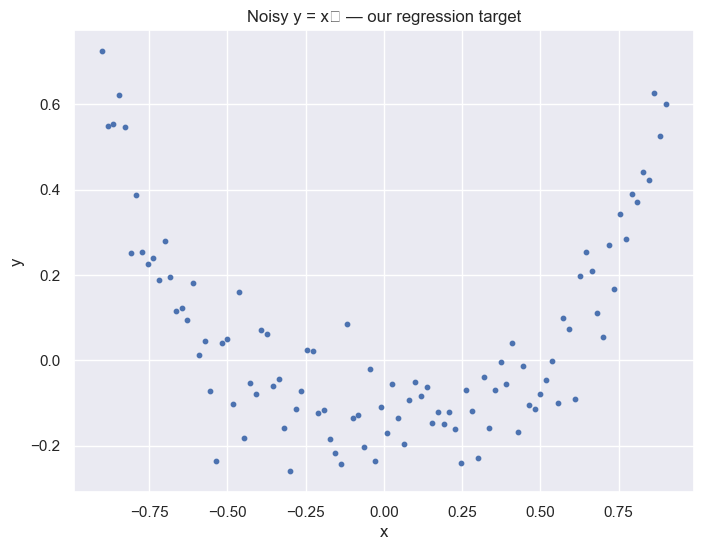

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split

# ── Generate a noisy curve y = x^4 + noise (same as lecture) ─────────────
np.random.seed(0)
X_reg = np.linspace(-0.9, 0.9, 100)
y_reg = X_reg ** 4 + np.random.normal(-0.09, 0.09, 100)

plt.figure(figsize=(8, 6))
plt.scatter(X_reg, y_reg, s=10)
plt.title("Noisy y = x⁴ — our regression target")
plt.xlabel("x")
plt.ylabel("y")
plt.show()


/var/folders/z_/96szh7017rv42ny6tbyw5nj40000gn/T/ipykernel_52348/621146157.py:39: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/z_/96szh7017rv42ny6tbyw5nj40000gn/T/ipykernel_52348/621146157.py:39: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/z_/96szh7017rv42ny6tbyw5nj40000gn/T/ipykernel_52348/621146157.py:39: UserWarning: Glyph 8323 (\N{SUBSCRIPT THREE}) missing from font(s) Arial.
  plt.tight_layout()
/opt/anaconda3/envs/myenv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/myenv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/myenv/lib/python3.11/site-packages/IPython/core/pyl

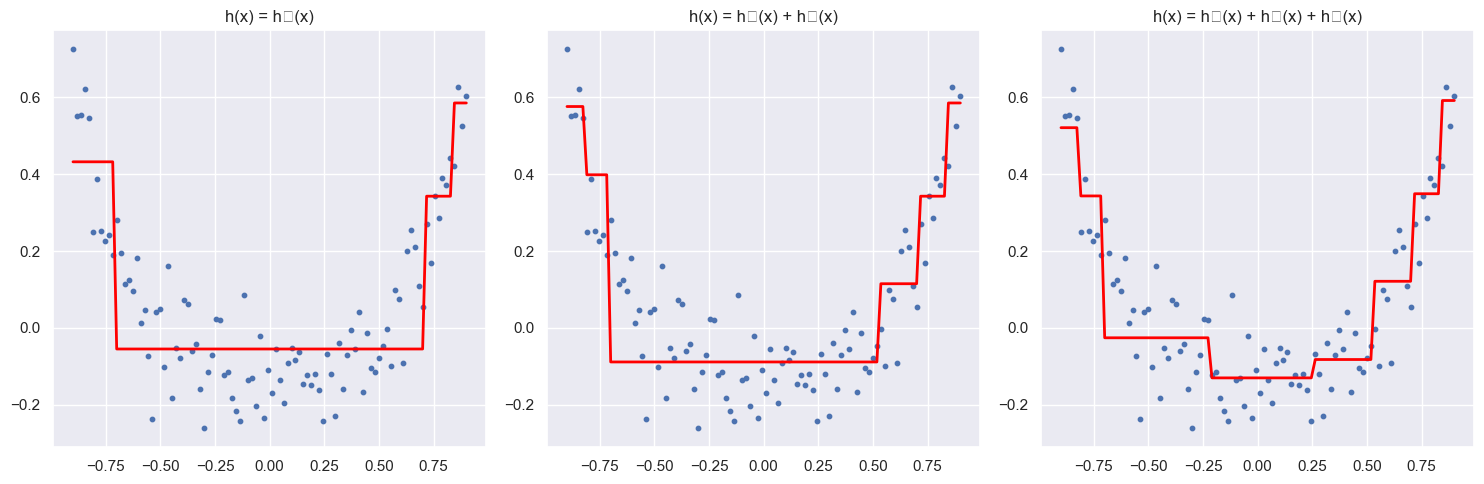

Each additional tree brings the prediction closer to the true curve.


In [10]:
# ── Manual gradient boosting: 3 trees (from scratch) ─────────────────────
X_new = X_reg.reshape(-1, 1)
X_tr, X_te, y_tr, y_te = train_test_split(X_new, y_reg, test_size=0.4, random_state=42)

# Tree 1: fit the original data
tree_reg1 = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_reg1.fit(X_tr, y_tr)

# Residual 1: what Tree 1 got wrong
residual1  = y_tr - tree_reg1.predict(X_tr)

# Tree 2: fit the RESIDUAL (the mistake of Tree 1)
tree_reg2 = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_reg2.fit(X_tr, residual1)

# Residual 2: what Tree 1 + Tree 2 together still got wrong
residual2  = residual1 - tree_reg2.predict(X_tr)

# Tree 3: fit that remaining error
tree_reg3 = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_reg3.fit(X_tr, residual2)

# ── Plot the ensemble improving over three steps ───────────────────────────
X_plot  = X_reg.reshape(-1, 1)
pred1   = tree_reg1.predict(X_plot)
pred12  = pred1  + tree_reg2.predict(X_plot)
pred123 = pred12 + tree_reg3.predict(X_plot)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, pred, title in zip(axes,
                            [pred1, pred12, pred123],
                            ["h(x) = h₁(x)",
                             "h(x) = h₁(x) + h₂(x)",
                             "h(x) = h₁(x) + h₂(x) + h₃(x)"]):
    ax.scatter(X_reg, y_reg, s=10)
    ax.plot(X_reg, pred, color="red", linewidth=2)
    ax.set_title(title, fontsize=12)

plt.tight_layout()
plt.show()

print("Each additional tree brings the prediction closer to the true curve.")


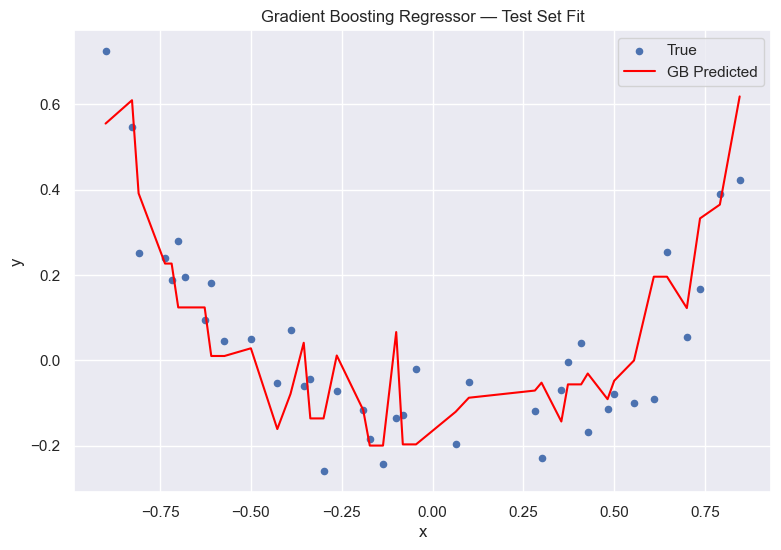

In [11]:
# ── Scikit-learn's GradientBoostingRegressor (much more efficient) ────────
from sklearn.ensemble import GradientBoostingRegressor

gb_reg = GradientBoostingRegressor(
    max_depth    = 2,
    n_estimators = 150,    # 150 trees in sequence
    learning_rate= 0.2,    # each tree contributes 20 % of its prediction
    random_state = 42
)
gb_reg.fit(X_tr, y_tr)

# ── Plot predictions vs. true values on the test set ─────────────────────
y_pred_test = gb_reg.predict(X_te)

# Sort by x so the line looks clean
order = np.argsort(X_te.flatten())
plt.figure(figsize=(9, 6))
plt.scatter(X_te[order], y_te[order], label="True", s=20)
plt.plot(X_te[order], y_pred_test[order], color="red", label="GB Predicted")
plt.legend()
plt.title("Gradient Boosting Regressor — Test Set Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.show()


### Gradient Boosting for Classification

For classification (our iris problem), scikit-learn's
`GradientBoostingClassifier` works the same way under the hood —
it just uses a different loss function (log-loss instead of squared error).


In [12]:
from sklearn.ensemble import GradientBoostingClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X_2d, y, test_size=0.4, random_state=42
)

gb_clf = GradientBoostingClassifier(
    max_depth    = 2,
    n_estimators = 100,
    learning_rate= 0.1,
    random_state = 42
)
gb_clf.fit(X_train, y_train)

print("Gradient Boosting Classifier accuracy:", accuracy_score(y_test, gb_clf.predict(X_test)))
print(classification_report(y_test, gb_clf.predict(X_test)))


Gradient Boosting Classifier accuracy: 0.675
              precision    recall  f1-score   support

           0       0.73      0.70      0.71        23
           1       0.61      0.65      0.63        17

    accuracy                           0.68        40
   macro avg       0.67      0.67      0.67        40
weighted avg       0.68      0.68      0.68        40



---

## Final comparison of all methods

Let's run every method side-by-side on the same split and summarise the results.


In [13]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    VotingClassifier, BaggingClassifier, RandomForestClassifier,
    AdaBoostClassifier, GradientBoostingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_4d, y, test_size=0.4, random_state=42
)

models = {
    "Decision Tree (single)": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Hard Voting": VotingClassifier(estimators=[
        ("lr", LogisticRegression(max_iter=1000)),
        ("rf", RandomForestClassifier(random_state=42)),
        ("svm", SVC())
    ], voting="hard"),
    "Bagging (500 stumps)": BaggingClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=500, bootstrap=True, n_jobs=-1, random_state=42
    ),
    "Random Forest (500 trees)": RandomForestClassifier(
        max_depth=3, n_estimators=500, n_jobs=-1, random_state=42
    ),
    "AdaBoost (200 stumps)": AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=200, learning_rate=0.5, random_state=42
    ),
    "Gradient Boosting (100 trees)": GradientBoostingClassifier(
        max_depth=2, n_estimators=100, learning_rate=0.1, random_state=42
    ),
}

print(f"{'Method':<35} {'Test Accuracy':>13}")
print("-" * 50)
for name, clf in models.items():
    clf.fit(X_train, y_train)
    acc = accuracy_score(y_test, clf.predict(X_test))
    print(f"{name:<35} {acc:>13.3f}")


Method                              Test Accuracy
--------------------------------------------------
Decision Tree (single)                      0.825
Hard Voting                                 0.975
Bagging (500 stumps)                        0.900
Random Forest (500 trees)                   0.900
AdaBoost (200 stumps)                       0.900
Gradient Boosting (100 trees)               0.850


---

## Summary and key takeaways

| Method | How diversity is created | Combination |
|--------|--------------------------|-------------|
| **Hard Voting** | Different model architectures | Simple majority vote |
| **Bagging** | Different bootstrap samples | Simple majority vote |
| **Random Forest** | Bootstrap + random feature subset | Simple majority vote |
| **AdaBoost** | Sequential, reweighted samples | Weighted vote by model accuracy |
| **Gradient Boosting** | Sequential, fits residual errors | Sum of all trees |

### When to use each method

- **Hard Voting** — when you have several strong models that disagree with each other.
- **Bagging / Random Forest** — when your single model overfits (high variance).
- **AdaBoost** — when your single model underfits (high bias) — boosting reduces bias.
- **Gradient Boosting** — generally the strongest performer; use when you need state-of-the-art accuracy.

### Limitations

1. **Training time** — ensemble methods train multiple models, so they are always slower.
2. **Interpretability** — hard to explain *why* an ensemble made a specific prediction.
3. **Diminishing returns** — after a point, adding more models barely helps.

---

**Next up:** Unsupervised Learning — PCA and K-Means Clustering!
